In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb

# Get run(s)

In [ ]:
def get_run_paths(entity: str, project: str, run_names: list[str]) -> dict[str, str]:
    """
    Given an entity, project, and a list of run names, return a dict
    mapping each found run name -> run path (entity/project/run_id).

    Args:
        entity (str): W&B entity (user or team)
        project (str): W&B project name
        run_names (list[str]): list of run display names

    Returns:
        dict[str, str]: mapping {run_name: run_path}
    """
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}")
    run_map = {}

    for run in runs:
        if run.name in run_names:
            run_map[run.name] = run.path  # e.g. ['entity', 'project', 'run_id']

    # Flatten the path list into a string: "entity/project/run_id"
    return {name: "/".join(path) for name, path in run_map.items()}


def load_logical_run_history(api, run_spec, keys=None):
    """
    Load the history of a *logical* run as a single DataFrame aligned by `_step`.

    A logical run may be either:
      - a single W&B run path (str), or
      - a list of paths that form one continuous training trajectory, e.g. a run
        that crashed and was resumed via `--resume_from_checkpoint`:
        ["crashed-run-path", "resumed-run-path"].

    When concatenating segments, the tail of each earlier segment that overlaps
    the next segment (the steps re-executed after resuming from the last
    checkpoint) is trimmed away, so the resulting history is exactly one clean
    0->1000-step trajectory with no duplicated steps.

    Args:
        api: an authenticated wandb.Api() instance.
        run_spec: str | list[str] -- the logical run specification.
        keys: metric keys to fetch (passed to scan_history). None scans every
              column (required for wildcard-prefixed keys like "timesteps/t=").

    Returns:
        pd.DataFrame with one row per logged step, plus an `_step` column.
    """
    segments = [run_spec] if isinstance(run_spec, str) else list(run_spec)
    scan_keys = None if keys is None else list(dict.fromkeys(["_step", *keys]))

    frames = []
    for path in segments:
        run = api.run(path)
        rows = list(run.scan_history(keys=scan_keys))
        if rows:
            frames.append(pd.DataFrame(rows))

    if not frames:
        return pd.DataFrame()

    trimmed = [frames[0]]
    for prev, nxt in zip(frames, frames[1:]):
        if "_step" in nxt.columns and not nxt.empty:
            resume_step = nxt["_step"].min()
            trimmed[-1] = trimmed[-1][trimmed[-1]["_step"] < resume_step]
        trimmed.append(nxt)

    out = pd.concat(trimmed, ignore_index=True)
    # Defensive: sort by _step and drop any duplicate steps so that
    # array[-1] / last-k windows are the true endpoint (not insertion order).
    # scan_history already returns sorted, unique-step rows, but this makes
    # the result correct by construction regardless of the data source.
    if "_step" in out.columns and not out.empty:
        out = (out.sort_values("_step")
                  .drop_duplicates("_step", keep="last")
                  .reset_index(drop=True))
    return out


In [3]:
entity = "amandajm2305-furg"  # replace with your W&B entity
project = "tao-diffusion"

# Round 1 + Round 2 run names (church aesthetic experiment).
# `vibrant-water-28` is an extra early SNR run kept for a later, deeper SNR
# analysis; it is intentionally NOT part of the main comparison below.
run_names = [
    # --- Round 1 ---
    "tough-tree-17",       # Full Trajectory
    "jumping-fog-10",      # Uniform
    "hardy-bush-14",       # Sensitivity
    "blooming-shadow-13",  # Variance
    "dandy-moon-12",       # SNR
    "stilted-dawn-16",     # Sensitivity x SNR
    "stellar-universe-15", # Variance x SNR
    # --- Round 2 ---
    "super-puddle-42",     # Full Trajectory
    "jolly-firebrand-39",  # Uniform
    "worldly-surf-35",     # Sensitivity  (crashed @650, resumed)
    "valiant-capybara-38", # Sensitivity  (resume of worldly-surf-35)
    "earnest-pine-31",     # Variance     (crashed @460, resumed)
    "wise-smoke-32",       # Variance     (resume of earnest-pine-31)
    "noble-frost-43",      # SNR
    "vocal-river-30",      # Sensitivity x SNR
    "apricot-violet-29",   # Variance x SNR
    # --- Extra (later analysis only) ---
    "vibrant-water-28",    # SNR (extra run)
]
run_paths = get_run_paths(entity, project, run_names)
run_paths


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/amanda/.netrc.


{'blooming-shadow-13': 'amandajm2305-furg/tao-diffusion/uyxaqwg4',
 'stellar-universe-15': 'amandajm2305-furg/tao-diffusion/xwxqwnkj',
 'tough-tree-17': 'amandajm2305-furg/tao-diffusion/w252klko',
 'jumping-fog-10': 'amandajm2305-furg/tao-diffusion/cuhglb20',
 'dandy-moon-12': 'amandajm2305-furg/tao-diffusion/c93hsoqx',
 'stilted-dawn-16': 'amandajm2305-furg/tao-diffusion/vp0vdvoq',
 'hardy-bush-14': 'amandajm2305-furg/tao-diffusion/1imueiel',
 'vibrant-water-28': 'amandajm2305-furg/tao-diffusion/it81t7je',
 'apricot-violet-29': 'amandajm2305-furg/tao-diffusion/n6n0suqx',
 'vocal-river-30': 'amandajm2305-furg/tao-diffusion/03lpuhr7',
 'earnest-pine-31': 'amandajm2305-furg/tao-diffusion/dqd49v0p',
 'wise-smoke-32': 'amandajm2305-furg/tao-diffusion/45vu2f7t',
 'worldly-surf-35': 'amandajm2305-furg/tao-diffusion/pis04h44',
 'valiant-capybara-38': 'amandajm2305-furg/tao-diffusion/s4rqez90',
 'jolly-firebrand-39': 'amandajm2305-furg/tao-diffusion/l0m8eqmt',
 'super-puddle-42': 'amandajm2305

# Training curves

In [4]:
def plot_wandb_metrics(runs_dict, metrics_dict, dpi=200):
    """
    Plot specified metrics for multiple wandb runs using the same seaborn style as plot_distributions_per_metric.

    Each entry in runs_dict is a list of logical runs; a logical run may be a
    single run path (str) or a list of paths forming one trajectory (e.g. a
    crashed+resumed run). Curves are averaged across logical runs within a label
    and the std is shown as a shaded band.

    Args:
        runs_dict (dict): {label: [run_spec, ...]} where run_spec is str | list[str]
        metrics_dict (dict): {wandb_metric: metric_label}
        dpi (int): Dots per inch for high-resolution plots (default: 200)
    """
    sns.set(style="whitegrid", font_scale=1.2, context="paper")
    color_palette = sns.color_palette("Set2", n_colors=len(runs_dict) + 1)
    marker_style = "o"

    api = wandb.Api()
    n_metrics = len(metrics_dict)
    fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 6))
    if n_metrics == 1:
        axes = [axes]

    for i_label, (label, run_specs) in enumerate(runs_dict.items()):
        # Treat a bare str as a single-run group, list as one or more logical runs.
        run_specs = [run_specs] if isinstance(run_specs, str) else list(run_specs)
        scan_keys = list(metrics_dict.keys())
        metric_histories = {metric: [] for metric in metrics_dict.keys()}

        for run_spec in run_specs:
            df = load_logical_run_history(api, run_spec, keys=scan_keys)
            if df.empty:
                continue
            for metric in metrics_dict.keys():
                if metric in df:
                    metric_histories[metric].append(df[metric].values)

        # Now plot mean + variability for each metric
        for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
            curves = metric_histories[metric]
            if not curves:
                continue
            max_len = max(len(arr) for arr in curves)
            metric_matrix = np.full((len(curves), max_len), np.nan)
            for i, arr in enumerate(curves):
                metric_matrix[i, : len(arr)] = arr
            mean = np.nanmean(metric_matrix, axis=0)
            std = np.nanstd(metric_matrix, axis=0)
            x = np.arange(max_len)
            axes[idx].plot(
                x,
                mean,
                label=label,
                color=color_palette[i_label + 1],
                linewidth=1.5,
                marker=marker_style,
                markersize=3,
                alpha=0.7,
            )
            axes[idx].fill_between(
                x,
                mean - std,
                mean + std,
                color=color_palette[i_label + 1],
                alpha=0.30,
                linewidth=0,
            )

    for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
        axes[idx].set_xlabel("Iteration")
        axes[idx].set_ylabel(metric_label)
        axes[idx].legend()
        axes[idx].grid(True, linestyle=":", alpha=0.7)
        # axes[idx].set_yscale('log')  # Activate log scale in Y axis

    plt.tight_layout()
    plt.show()


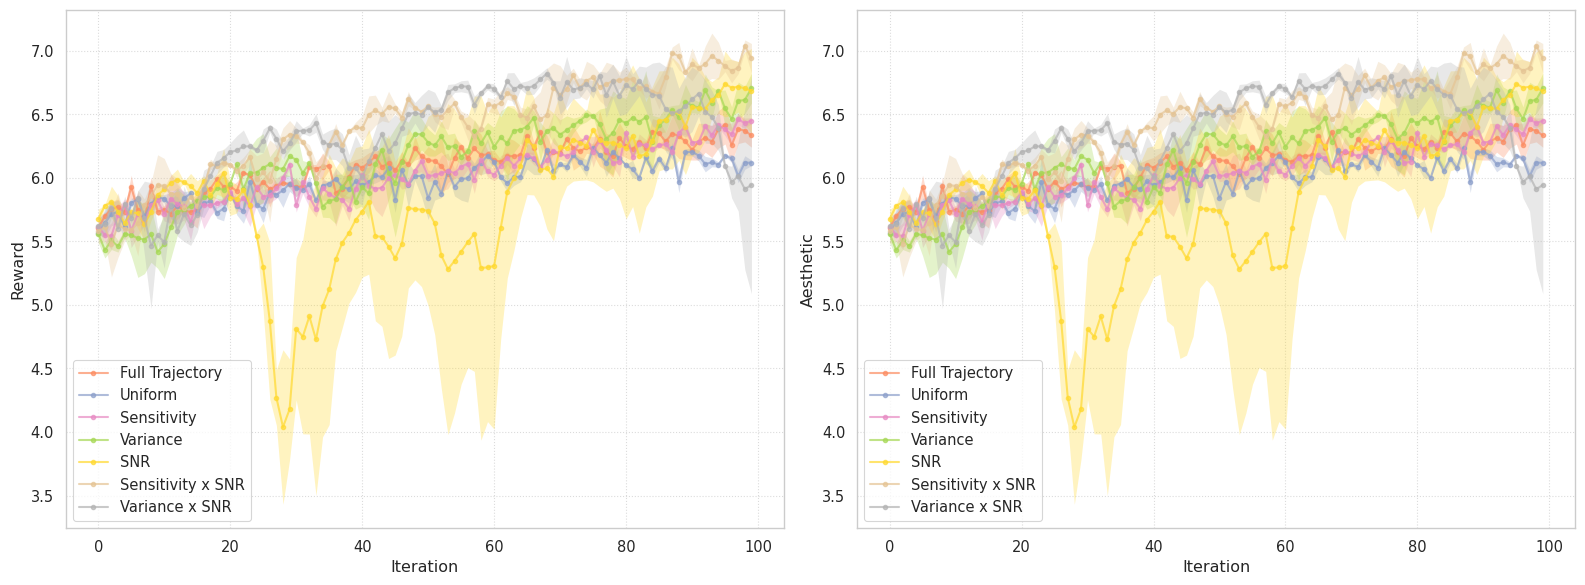

In [5]:
# Each strategy lists its independent replicate trajectories (rounds 1 & 2).
# A nested list [a, b] denotes ONE trajectory made of segment `a` followed by
# segment `b` (a run that crashed and was resumed from checkpoint). The helper
# trims the re-executed overlap so it is treated as a single clean run.
runs = {
    "Full Trajectory": [
        run_paths["tough-tree-17"],
        run_paths["super-puddle-42"],
    ],
    "Uniform": [
        run_paths["jumping-fog-10"],
        run_paths["jolly-firebrand-39"],
    ],
    "Sensitivity": [
        run_paths["hardy-bush-14"],
        [run_paths["worldly-surf-35"], run_paths["valiant-capybara-38"]],  # crashed @650 -> resumed
    ],
    "Variance": [
        run_paths["blooming-shadow-13"],
        [run_paths["earnest-pine-31"], run_paths["wise-smoke-32"]],  # crashed @460 -> resumed
    ],
    "SNR": [
        run_paths["dandy-moon-12"],       # Round 1
        run_paths["noble-frost-43"],      # Round 2
        # Extra early SNR run kept for a later, deeper SNR analysis
        # (intentionally NOT part of the main comparison):
        # run_paths["vibrant-water-28"],
    ],
    "Sensitivity x SNR": [
        run_paths["stilted-dawn-16"],
        run_paths["vocal-river-30"],
    ],
    "Variance x SNR": [
        run_paths["stellar-universe-15"],
        run_paths["apricot-violet-29"],
    ],
}
metrics = {
    "train/reward": "Reward",
    "train/aesthetics_score": "Aesthetic",
}
plot_wandb_metrics(runs, metrics)


# Speedup vs. Full Trajectory baseline

In [6]:
def compute_speedup_table(
    runs_dict: dict[str, list],
    metric: str = "train/reward",
    baseline_label: str = "Full Trajectory",
) -> pd.DataFrame:
    """
    Compute speedup table comparing all strategies to the baseline.

    Each entry in runs_dict is a list of logical runs (str | list[str]); curves
    are averaged across logical runs within a label before computing the speedup.
    """
    api = wandb.Api()

    def avg_curve(run_specs) -> np.ndarray:
        run_specs = [run_specs] if isinstance(run_specs, str) else list(run_specs)
        curves = []
        for run_spec in run_specs:
            df = load_logical_run_history(api, run_spec, keys=[metric])
            if df.empty or metric not in df:
                continue
            curves.append(df[metric].values)
        if not curves:
            return np.array([])
        max_len = max(len(c) for c in curves)
        curve_matrix = np.full((len(curves), max_len), np.nan)
        for i, c in enumerate(curves):
            curve_matrix[i, :len(c)] = c
        return np.nanmean(curve_matrix, axis=0)

    baseline_curve = avg_curve(runs_dict[baseline_label])
    if baseline_curve.size == 0:
        raise ValueError(f"No {metric} data found for baseline strategy: {baseline_label}")

    target = np.nanmax(baseline_curve)
    baseline_step = int(np.nanargmax(baseline_curve))

    rows = []
    for label, specs in runs_dict.items():
        curve = avg_curve(specs)
        if curve.size == 0:
            rows.append({"run": label, "step": None, "speedup": None, "best_reward": None})
            continue
        reached = np.where(curve >= target)[0]
        if reached.size == 0:
            rows.append({
                "run": label,
                "step": None,
                "speedup": None,
                "best_reward": float(np.nanmax(curve)),
            })
            continue
        step = int(reached[0])
        speedup = baseline_step / step if step > 0 else np.inf
        rows.append({
            "run": label,
            "step": step,
            "speedup": speedup,
            "best_reward": float(np.nanmax(curve)),
        })

    df = pd.DataFrame(rows)
    df.attrs["baseline_step"] = baseline_step
    df.attrs["baseline_target"] = float(target)
    return df

speedup_df = compute_speedup_table(runs)
speedup_df


def compute_summary_table(
    runs_dict: dict[str, list],
    metric: str = "train/reward",
    baseline_label: str = "Full Trajectory",
    final_k: int = 10,
) -> pd.DataFrame:
    """
    Per-trial summary statistics (Version B).

    Each strategy entry is a list of *logical runs* (str | list[str]); each
    logical run is one independent trial (a single run, or a crashed+resumed
    trajectory). Statistics are computed within each trial first, then
    aggregated across trials, so the point estimate and its min-max range are
    over the SAME statistic. (The average-first alternative `max(mean-curve)`
    is biased low by Jensen's inequality and can fall outside its own range.)

    Columns:
      best     - peak reward per trial; mean (min-max) across trials
      final    - literal last logged value per trial; mean (min-max)
      final_k  - mean of the last `final_k` logged values per trial (robust to
                 a single noisy final step); mean (min-max)
      speedup  - per-trial first-reach speedup vs the baseline, averaged over
                 the trials that reached the target; n_reached / n reports how
                 many did. The baseline is 1.00x by construction.
    The baseline target/step come from the peak of the baseline's MEAN curve,
    giving one common reference for every trial and strategy.
    """
    api = wandb.Api()

    def trial_curves(specs) -> list[np.ndarray]:
        curves = []
        for spec in specs:
            df = load_logical_run_history(api, spec, keys=[metric])
            if df.empty or metric not in df:
                continue
            v = df[metric].dropna().to_numpy()
            if v.size:
                curves.append(v)
        return curves

    def _mean_curve(curves) -> np.ndarray:
        if not curves:
            return np.array([])
        max_len = max(len(c) for c in curves)
        m = np.full((len(curves), max_len), np.nan)
        for i, c in enumerate(curves):
            m[i, : len(c)] = c
        return np.nanmean(m, axis=0)

    base_curves = trial_curves(runs_dict[baseline_label])
    base_mean = _mean_curve(base_curves)
    if base_mean.size == 0:
        raise ValueError(f"No {metric} data for baseline '{baseline_label}'")
    target = float(np.nanmax(base_mean))
    baseline_step = int(np.nanargmax(base_mean))

    rows = []
    for label, specs in runs_dict.items():
        curves = trial_curves(specs)
        if not curves:
            rows.append({"strategy": label, "n": 0})
            continue
        n = len(curves)
        bests = [float(np.max(c)) for c in curves]
        finals = [float(c[-1]) for c in curves]
        k = final_k
        finals_k = [float(np.mean(c[-min(k, len(c)):])) for c in curves]
        if label == baseline_label:
            sps = [1.0] * n
            n_reached = n
        else:
            sps = []
            for c in curves:
                reached = np.where(c >= target)[0]
                if reached.size and reached[0] > 0:
                    sps.append(baseline_step / int(reached[0]))
            n_reached = len(sps)
        rows.append(
            {
                "strategy": label,
                "n": n,
                "best_mean": np.mean(bests),
                "best_min": min(bests),
                "best_max": max(bests),
                "final_mean": np.mean(finals),
                "final_min": min(finals),
                "final_max": max(finals),
                f"final_{k}_mean": np.mean(finals_k),
                f"final_{k}_min": min(finals_k),
                f"final_{k}_max": max(finals_k),
                "speedup_mean": float(np.mean(sps)) if sps else np.nan,
                "n_reached": n_reached,
            }
        )

    df = pd.DataFrame(rows)
    df.attrs["baseline_step"] = baseline_step
    df.attrs["baseline_target"] = target
    df.attrs["final_k"] = final_k
    return df


def format_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """Render compute_summary_table output as mean (min-max) strings."""
    k = df.attrs.get("final_k", 10)

    def rng(c_mean, c_min, c_max, digits=2):
        same = df[c_min] == df[c_max]
        base = df[c_mean].round(digits).astype(str)
        lo = df[c_min].round(digits).astype(str)
        hi = df[c_max].round(digits).astype(str)
        return np.where(same, base, base + " (" + lo + "-" + hi + ")")

    def spd():
        none_mask = df["n_reached"] == 0
        full_mask = df["n_reached"] == df["n"]
        val = df["speedup_mean"].round(2).astype(str) + "x"
        val_partial = (
            df["speedup_mean"].round(2).astype(str)
            + "x ["
            + df["n_reached"].astype(str)
            + "/"
            + df["n"].astype(str)
            + "]"
        )
        return np.where(none_mask, "-", np.where(full_mask, val, val_partial))

    return pd.DataFrame(
        {
            "Strategy": df["strategy"],
            "n": df["n"],
            "Best R": rng("best_mean", "best_min", "best_max"),
            "Final R": rng("final_mean", "final_min", "final_max"),
            f"Final R (last {k})": rng(f"final_{k}_mean", f"final_{k}_min", f"final_{k}_max"),
            "Speedup": spd(),
        }
    )


summary_df = compute_summary_table(runs)
print(
    f"Baseline target = {summary_df.attrs['baseline_target']:.2f} "
    f"@ step {summary_df.attrs['baseline_step']}  "
    f"(final_k = {summary_df.attrs['final_k']})"
)
format_summary_table(summary_df)


Baseline target = 6.42 @ step 95  (final_k = 10)


,Strategy,n,Best R,Final R,Final R (last 10),Speedup
0,Full Trajectory,2,6.46 (6.35-6.57),6.33 (6.24-6.43),6.32 (6.2-6.44),1.0x
1,Uniform,2,6.27 (6.24-6.31),6.12 (6.09-6.14),6.13 (6.11-6.15),-
2,Sensitivity,2,6.49 (6.47-6.51),6.45 (6.42-6.47),6.38 (6.37-6.38),1.03x
3,Variance,2,6.76 (6.68-6.84),6.7 (6.59-6.82),6.6 (6.5-6.7),1.67x
4,SNR,2,6.77 (6.52-7.02),6.68 (6.35-7.02),6.65 (6.39-6.9),1.46x
5,Sensitivity x SNR,2,7.08 (7.02-7.14),6.94 (6.82-7.06),6.91 (6.87-6.95),2.86x
6,Variance x SNR,2,6.89 (6.82-6.95),5.94 (5.09-6.8),6.26 (5.96-6.56),2.93x


# Sampled timestep distribution

In [ ]:
def plot_timestep_distributions(
    runs_dict: dict[str, list],
    dpi: int = 150,
    ncols: int = 3,
):
    """
    For each group of runs, plot the average normalized timestep sampling distribution
    as a bar chart. Fixed number of columns, rows adapt to the number of groups.

    Each logical run's distribution is normalized to frequency (fraction of samples
    at each timestep), then averaged across logical runs within the group. A logical
    run may be a single path (str) or a list of paths forming one trajectory.

    Args:
        runs_dict: {label: [run_spec, ...]} -- run_spec is str | list[str]
        dpi: figure resolution
        ncols: number of subplot columns (default: 3)
    """
    sns.set(style="whitegrid", font_scale=1.2, context="paper")
    api = wandb.Api()
    color_palette = sns.color_palette("Set2", n_colors=len(runs_dict) + 1)

    n_groups = len(runs_dict)
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows), sharey=False, dpi=dpi)
    axes = np.array(axes).flatten()

    for ax_idx, (label, run_specs) in enumerate(runs_dict.items()):
        ax = axes[ax_idx]
        run_specs = [run_specs] if isinstance(run_specs, str) else list(run_specs)

        freq_series_list = []

        for run_spec in run_specs:
            df = load_logical_run_history(api, run_spec, keys=None)  # full scan for "timesteps/t=" cols
            if df.empty:
                continue

            ts_cols = [c for c in df.columns if c.startswith("timesteps/t=")]
            if not ts_cols:
                continue

            sums = df[ts_cols].sum(axis=0)
            timestep_index = [int(c.split("timesteps/t=")[1]) for c in sums.index]
            series = pd.Series(sums.values, index=timestep_index)
            total = series.sum()
            if total > 0:
                series = series / total
            freq_series_list.append(series)

        if not freq_series_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(label)
            continue

        combined = pd.concat(freq_series_list, axis=1).mean(axis=1).sort_index()
        timesteps = combined.index.values
        freqs = combined.values

        bar_width = np.min(np.diff(timesteps)) * 0.8 if len(timesteps) > 1 else 10
        ax.bar(timesteps, freqs, width=bar_width, color=color_palette[ax_idx + 1], align="center")
        ax.set_xlabel("Diffusion Timestep")
        ax.set_ylabel("Normalized frequency")
        ax.set_title(label)
        ax.set_xlim([timesteps.min() - bar_width, timesteps.max() + bar_width])
        ax.grid(axis="y", linestyle=":", alpha=0.4)

        ax.set_xticks(timesteps)
        ax.set_xticklabels([str(t) for t in timesteps], rotation=45, ha="right")

    for ax in axes[n_groups:]:
        ax.set_visible(False)

    fig.suptitle("Sampled Timestep Distribution per Training Strategy", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_timestep_distributions(runs)

# Gradient analysis

In [ ]:
def plot_gradient_stats(
    runs_dict: dict[str, str],
    dpi: int = 150,
):
    """
    For each gradient metric (norm, mean, std), plot one figure with one subplot per run.
    Primary axis: average gradient statistic per diffusion timestep (line).
    Secondary axis: number of times each timestep was sampled during training (bars).

    Since each timestep is only logged when sampled, values are averaged across all steps
    where they were recorded (NaN steps are skipped). The count bars provide context for
    how reliable each average is.

    Args:
        runs_dict: {label: run_path} — one entry per run to display
        dpi: figure resolution
    """
    sns.set(style="whitegrid", font_scale=1.2, context="paper")
    api = wandb.Api()

    metrics = [
        ("grad_inc_norm", "Gradient Demeaned Norm"),
        ("grad_inc_mean", "Gradient Mean"),
        ("grad_inc_std", "Gradient Standard Deviation"),
    ]

    n_runs = len(runs_dict)

    for metric_key, metric_label in metrics:
        fig, axes = plt.subplots(1, n_runs, figsize=(8 * n_runs, 5), sharey=False, dpi=dpi)
        if n_runs == 1:
            axes = [axes]

        for ax, (label, run_path) in zip(axes, runs_dict.items()):
            run = api.run(run_path)

            # scan_history keys filter doesn't match nested-looking keys (e.g. "grad_inc_norm/t=620")
            # reliably — scan everything and filter columns after, same as plot_overall_timestep_hist
            df = pd.DataFrame(list(run.scan_history()))
            ts_cols = sorted(
                [c for c in df.columns if c.startswith(f"{metric_key}/t=")],
                key=lambda c: int(c.split("=")[1]),
            )

            if not ts_cols:
                ax.text(0.5, 0.5, "No gradient data\nfor this run", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(label)
                print(f"Warning: no '{metric_key}' data found for run '{label}' ({run_path})")
                continue

            df = df[ts_cols]
            diffusion_timesteps = [int(c.split("=")[1]) for c in ts_cols]

            avg = df.mean(axis=0).values
            # count() gives number of non-NaN values per column = times each timestep was sampled
            counts = df.count(axis=0).values

            bar_width = np.min(np.diff(diffusion_timesteps)) * 0.8 if len(diffusion_timesteps) > 1 else 10

            # Secondary axis: timestep sample counts as background bars
            ax2 = ax.twinx()
            ax2.bar(diffusion_timesteps, counts, width=bar_width, color="steelblue", alpha=0.2, zorder=1)
            ax2.set_ylabel("Sample count", fontsize=8, color="steelblue")
            ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=7)

            # Bring primary axis in front of bars
            ax.set_zorder(ax2.get_zorder() + 1)
            ax.patch.set_visible(False)

            ax.plot(diffusion_timesteps, avg, linewidth=2, color="C0", zorder=2)
            ax.set_xlabel("Diffusion Timestep")
            ax.set_ylabel(metric_label)
            ax.set_title(label)
            ax.grid(True, linestyle=":", alpha=0.7)

        fig.suptitle(f"{metric_label} Across Diffusion Timesteps During Fine-Tuning", fontsize=14)
        plt.tight_layout()
        plt.show()

In [ ]:
grad_run_names = [
    "stilted-dew-113",
    "avid-darkness-30",
    "brisk-darkness-105",
]

grad_run_paths = get_run_paths(entity, project, grad_run_names)
grad_run_paths

In [ ]:
plot_gradient_stats({name: grad_run_paths[name] for name in grad_run_names})

# Final images plot

In [ ]:
import os
from collections.abc import Sequence

import wandb
from PIL import Image


def _get_step_images_for_run(
    run: wandb.apis.public.Run,
    out_dir: str,
    history_key: str,
    which: str = "last",  # "first" or "last"
) -> tuple[int | None, list[Image.Image]]:
    """
    Fetch eval images from either the first or last step of a run.
    Returns (step, [PIL.Image,...]).
    """
    os.makedirs(out_dir, exist_ok=True)

    chosen_step = None
    chosen_files = None

    for row in run.scan_history(keys=["_step", history_key]):
        step = row["_step"]
        meta = row.get(history_key) or {}
        filenames = meta.get("filenames", [])
        if not filenames:
            continue

        if which == "first":
            chosen_step = step
            chosen_files = filenames
            print("found first step")
            break
        elif which == "last":
            chosen_step = step
            chosen_files = filenames
        else:
            raise ValueError("which must be 'first' or 'last'")

    if chosen_files is None:
        return None, []

    # Download files (cached)
    imgs = []
    if chosen_step == "first":
        print(chosen_files)
    for rel in chosen_files:
        local = run.file(rel).download(
            root=out_dir,
            replace=False,
            exist_ok=True,
        )
        path = local if isinstance(local, str) else local.name
        imgs.append(Image.open(path).convert("RGB"))

    return chosen_step, imgs


def plot_runs_last_eval_with_pretrained(
    runs_dict: dict[str, str],
    n_images: int,
    sample_indices: Sequence[int] | None = None,
    out_dir: str = "frames",
    history_key: str = "eval/samples",
    suptitle: str | None = None,
):
    """
    - Input: dict of {column_name: run_path}
    - Adds a "pretrained" column from the first-step eval of the *first* run.
    - For each named run, uses the *last* eval step.
    - Samples fixed indices (same across all columns).
    - No whitespace between rows and columns.
    """
    api = wandb.Api()

    # Convert sample_indices -> final list
    if sample_indices is None:
        sample_indices = list(range(n_images))
    else:
        sample_indices = list(sample_indices)
        assert len(sample_indices) == n_images, "sample_indices length must equal n_images"

    # Get first run (to determine pretrained column)
    first_name = next(iter(runs_dict.keys()))
    first_run_path = runs_dict[first_name]
    first_run = api.run(first_run_path)

    # ---- PRETRAINED COLUMN (first step of first run) ----
    _, pretrained_imgs_full = _get_step_images_for_run(
        run=first_run,
        out_dir=out_dir,
        history_key=history_key,
        which="first",
    )

    def sample(imgs, idxs):
        return [imgs[i] for i in idxs if i < len(imgs)]

    pretrained_imgs = sample(pretrained_imgs_full, sample_indices)

    # ---- REMAINING RUNS (last step) ----
    imgs_by_name = {}
    min_len = len(pretrained_imgs)

    for name, path in runs_dict.items():
        run = api.run(path)
        _, imgs_full = _get_step_images_for_run(
            run=run,
            out_dir=out_dir,
            history_key=history_key,
            which="last",
        )
        sampled = sample(imgs_full, sample_indices)
        imgs_by_name[name] = sampled
        if sampled:
            min_len = min(min_len, len(sampled))

    if min_len == 0:
        print("No available images for requested indices.")
        return

    actual_rows = min(n_images, min_len)

    # ---- Create grid ----
    col_names = ["pretrained"] + list(runs_dict.keys())
    num_cols = len(col_names)
    num_rows = actual_rows

    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(3 * num_cols, 3 * num_rows),
        squeeze=False,
    )

    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    # Remove axes ticks
    for row in axes:
        for ax in row:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis("off")

    # ---- Fill PRETRAINED column ----
    for row in range(num_rows):
        axes[row][0].imshow(pretrained_imgs[row])
        axes[row][0].set_ylabel(f"idx {sample_indices[row]}", fontsize=7)

    axes[0][0].set_title("Original", fontsize=14)

    # ---- Fill RUN columns ----
    for col_idx, name in enumerate(runs_dict.keys(), start=1):
        imgs = imgs_by_name[name]
        for row in range(num_rows):
            axes[row][col_idx].imshow(imgs[row])
        axes[0][col_idx].set_title(name, fontsize=14)

    plt.show()

In [ ]:
# Representative single run per strategy for the image grid (round 2; for the
# crashed+resumed strategies the final -- resumed -- segment holds the last eval).
img_runs = {
    "Full Trajectory": run_paths["super-puddle-42"],
    "Uniform": run_paths["jolly-firebrand-39"],
    "Sensitivity": run_paths["valiant-capybara-38"],
    "Variance": run_paths["wise-smoke-32"],
    "SNR": run_paths["noble-frost-43"],
    "Sensitivity x SNR": run_paths["vocal-river-30"],
    "Variance x SNR": run_paths["apricot-violet-29"],
}
plot_runs_last_eval_with_pretrained(
    img_runs,
    n_images=20,
    # sample_indices =[0, 1, 3,4, 5, 6, 7, 10, 11, 13],
    out_dir="comparison",
    history_key="eval/samples",
    suptitle="Last eval images per run",
)


In [ ]:
def _get_best_step_images_for_run(
    run: wandb.apis.public.Run,
    out_dir: str,
    history_key: str = "eval/samples",
    metric_key: str = "eval/reward",
) -> tuple[int | None, list[Image.Image]]:
    """
    Fetch eval images from the step where `metric_key` is maximized.
    Only considers rows containing both the metric and the eval samples,
    so the chosen step is guaranteed to have downloadable images.
    Returns (step, [PIL.Image,...]).
    """
    os.makedirs(out_dir, exist_ok=True)

    best_step = None
    best_metric = -np.inf
    best_files = None

    for row in run.scan_history(keys=["_step", metric_key, history_key]):
        metric_val = row.get(metric_key)
        meta = row.get(history_key) or {}
        filenames = meta.get("filenames", [])
        if metric_val is None or not filenames:
            continue
        if metric_val > best_metric:
            best_metric = metric_val
            best_step = row["_step"]
            best_files = filenames

    if best_files is None:
        return None, []

    imgs = []
    for rel in best_files:
        local = run.file(rel).download(
            root=out_dir,
            replace=False,
            exist_ok=True,
        )
        path = local if isinstance(local, str) else local.name
        imgs.append(Image.open(path).convert("RGB"))

    return best_step, imgs


def plot_runs_best_eval_with_pretrained(
    runs_dict: dict[str, str],
    n_images: int,
    sample_indices: Sequence[int] | None = None,
    out_dir: str = "frames",
    history_key: str = "eval/samples",
    metric_key: str = "eval/reward",
):
    """
    - Input: dict of {column_name: run_path}
    - Adds a "pretrained" column from the first-step eval of the *first* run.
    - For each named run, uses the eval step that maximizes `metric_key`.
    - Samples fixed indices (same across all columns).
    - No whitespace between rows and columns.
    """
    api = wandb.Api()

    # Convert sample_indices -> final list
    if sample_indices is None:
        sample_indices = list(range(n_images))
    else:
        sample_indices = list(sample_indices)
        assert len(sample_indices) == n_images, "sample_indices length must equal n_images"

    # Get first run (to determine pretrained column)
    first_name = next(iter(runs_dict.keys()))
    first_run_path = runs_dict[first_name]
    first_run = api.run(first_run_path)

    # ---- PRETRAINED COLUMN (first step of first run) ----
    _, pretrained_imgs_full = _get_step_images_for_run(
        run=first_run,
        out_dir=out_dir,
        history_key=history_key,
        which="first",
    )

    def sample(imgs, idxs):
        return [imgs[i] for i in idxs if i < len(imgs)]

    pretrained_imgs = sample(pretrained_imgs_full, sample_indices)

    # ---- REMAINING RUNS (best eval step) ----
    imgs_by_name = {}
    best_step_by_name = {}
    min_len = len(pretrained_imgs)

    for name, path in runs_dict.items():
        run = api.run(path)
        step, imgs_full = _get_best_step_images_for_run(
            run=run,
            out_dir=out_dir,
            history_key=history_key,
            metric_key=metric_key,
        )
        best_step_by_name[name] = step
        sampled = sample(imgs_full, sample_indices)
        imgs_by_name[name] = sampled
        if sampled:
            min_len = min(min_len, len(sampled))

    if min_len == 0:
        print("No available images for requested indices.")
        return

    actual_rows = min(n_images, min_len)

    # ---- Create grid ----
    col_names = ["pretrained"] + list(runs_dict.keys())
    num_cols = len(col_names)
    num_rows = actual_rows

    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(3 * num_cols, 3 * num_rows),
        squeeze=False,
    )

    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    # Remove axes ticks
    for row in axes:
        for ax in row:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis("off")

    # ---- Fill PRETRAINED column ----
    for row in range(num_rows):
        axes[row][0].imshow(pretrained_imgs[row])
        axes[row][0].set_ylabel(f"idx {sample_indices[row]}", fontsize=7)

    axes[0][0].set_title("Original", fontsize=14)

    # ---- Fill RUN columns ----
    for col_idx, name in enumerate(runs_dict.keys(), start=1):
        imgs = imgs_by_name[name]
        for row in range(num_rows):
            axes[row][col_idx].imshow(imgs[row])
        step = best_step_by_name[name]
        title = f"{name}\n(step {step})" if step is not None else name
        axes[0][col_idx].set_title(title, fontsize=14)

    plt.show()

In [ ]:
plot_runs_best_eval_with_pretrained(
    img_runs,
    n_images=20,
    # sample_indices =[0, 1, 3,4, 5, 6, 7, 10, 11, 13],
    out_dir="comparison",
    history_key="eval/samples",
    metric_key="eval/reward",
)
